In [13]:
import matplotlib
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path
import boule as bl
import pandas as pd
import lonlat_labels as label
import cartopy.crs as ccrs
from plot_boundary import plot_boundaries_folder_on_ax
from matplotlib.colors import LightSource
import pyshtools as pysh

read data

In [14]:
# spectral domain inversion result
PROJECT_ROOT = Path.cwd().parent.parent
pkl_file = PROJECT_ROOT / "result/moho_inversion_result_1deg_35km.pkl"

with open(pkl_file, "rb") as f:
    obj = pickle.load(f, encoding="latin1")

    refden_moho_grid = obj['moho_grid']
    predict = obj['predict']
    observe = obj['observe']
    residuals = obj['residuals']
    rms = obj['rms']
    lon = obj['LON']
    lat = obj['LAT']
    
nlat_moho, nlon_moho = refden_moho_grid.shape
lon_moho = np.linspace(lon.min(), lon.max(), nlon_moho)
lat_moho = np.linspace(lat.min(), lat.max(), nlat_moho)

moho_grid = xr.DataArray(
    refden_moho_grid,  # 如果图东西颠倒或拉伸，改为 refden_moho_grid.T
    dims=("lat", "lon"),
    coords={"lat": lat_moho, "lon": lon_moho}
)

data_file = PROJECT_ROOT / "data/boueguer_frenquency_11km_d35km_1deg.csv"

df = pd.read_csv(data_file)
lon_raw = np.sort(df['lon'].unique())
lat_raw = np.sort(df['lat'].unique())
nlat = len(np.unique(lat_raw))
nlon = len(np.unique(lon_raw))

topo_grid  = df.pivot(index='lat', columns='lon', values='topo').loc[lat_raw, lon_raw].values
LON, LAT = np.meshgrid(lon_raw, lat_raw) 

arr = topo_grid*1e-3

topo_da = xr.DataArray(
    arr,  # 如果图东西颠倒或拉伸，改为 refden_moho_grid.T
    dims=("lat", "lon"),
    coords={"lat": lat_raw, "lon": lon_raw}
)

region = [lon_raw.min(), lon_raw.max(), lat_raw.min(), lat_raw.max()]

topo_da=topo_da.interp_like(moho_grid)

crustthick=topo_da+moho_grid
crustthick_tesseroid = crustthick.where(crustthick >= 0)

In [15]:
# sperical harmonic domain inversion result
data_filename = PROJECT_ROOT / "result/frequency_domain_run1.pkl"

with open(data_filename, "rb") as f:
    result = pickle.load(f)

thick = result["thick_grid"].data
nlat, nlon = thick.shape

lats = np.linspace(90, -90, nlat)
lons = np.linspace(0, 360, nlon, endpoint=False)

thick_da = xr.DataArray(thick, coords=[lats, lons], dims=["lat", "lon"])

# 转换到 [-180, 180] 并排序
da = thick_da.copy()
lon = ((da.lon + 180) % 360) - 180
da = da.assign_coords(lon=lon).sortby("lon")

crustthick_spherical = da

In [16]:
# topography data
LDEM=pysh.datasets.Moon.LDEM_shape_pa()
topo_grid=LDEM.expand(grid='DH',lmax=1200,extend=False)
topo=topo_grid.to_xarray()

plot result

In [17]:
from plot_basins import add_basin

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Times New Roman"],
    "axes.unicode_minus": False,

    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.2,
    "ytick.major.size": 3.2,
    "xtick.direction": "out",
    "ytick.direction": "out",

    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

In [18]:
# 月球主要撞击盆地列表，包含名称、中心经纬度和直径（单位：km）
basins = [
    ("IMB", "Imbrium", 33.0, -18.0, 580),
    ("SER", "Serenitatis", 27.0, 19.0, 370),
    ("CRI", "Crisium", 17.5, 58.5, 530),
    ("SMY", "Smythii", -2.0, 87.0, 420),
    ("HUM", "Humboldtianum", 61.0, 84.0, 300),
    ("MOS", "Moscoviense", 26.0, 147.0, 222.5),
    ("FSH", "Freundlich-Sharonov", 18.5, 175.0, 300),
    ("KOR", "Korolev", -4.5, -157.0, 220),
    ("HER", "Hertzsprung", 1.5, -128.5, 285),
    ("ORI", "Orientale", -20.0, -95.0, 465),
    ("HUMO", "Humorum", -24.0, -39.5, 410),
    ("NEC", "Nectaris", -16.0, 34.0, 430),
    ("APO", "Apollo", -36.0, -151.0, 252.5),
    ("MR", "Mendel-Rydberg", -50.0, -94.0, 315),
]

apollo_sites = {
    "Apollo 12": {"lat": -3.01, "lon": -23.42},
    "Apollo 14": {"lat": -3.64, "lon": -17.47},
    "Apollo 15": {"lat": 26.13, "lon":   3.63},
    "Apollo 16": {"lat": -8.97, "lon":  15.50},
}

In [19]:
# plot parameters and functions
cmap = plt.get_cmap("jet")
hillshade_alpha=0.35

def add_panel_label(ax, label, x=0.02, y=0.95):
    ax.text(x, y, label, transform=ax.transAxes, fontsize=15, fontweight='bold', va='top', ha='left')

def find_extreme(da):
    Z=da.values
    lat=da.lat
    lon=da.lon
    mask = np.isfinite(Z)

    # 最大
    imax = np.nanargmax(np.where(mask, Z, np.nan))
    ilat_max, ilon_max = np.unravel_index(imax, Z.shape)
    lat_max = float(lat[ilat_max])
    lon_max = float(lon[ilon_max])
    val_max = float(Z[ilat_max, ilon_max])

    # 最小
    imin = np.nanargmin(np.where(mask, Z, np.nan))
    ilat_min, ilon_min = np.unravel_index(imin, Z.shape)
    lat_min = float(lat[ilat_min])
    lon_min = float(lon[ilon_min])
    val_min = float(Z[ilat_min, ilon_min])

    return val_max,lon_max,lat_max,val_min,lon_min,lat_min

def mark_extreme(ax, lon0, lat0, value, marker, color, text_dx=2.0, text_dy=2.0):
    # 标记点（不那么夸张，更论文）
    ax.scatter(
        [lon0], [lat0],
        transform=ccrs.PlateCarree(),
        s=70,
        marker=marker,
        facecolor=color,
        edgecolor="0.1",
        linewidth=0.8,
        zorder=10
    )

    # 数值标注（稍微偏移，避免压在点上）
    ax.text(
        lon0 + text_dx, lat0 + text_dy,
        f"{value:.1f}",
        transform=ccrs.PlateCarree(),
        fontsize=9,
        ha="right", va="bottom",
        color="0.1",
        bbox=dict(facecolor="white", alpha=0.45, edgecolor="none", pad=0.8),
        zorder=11
    )

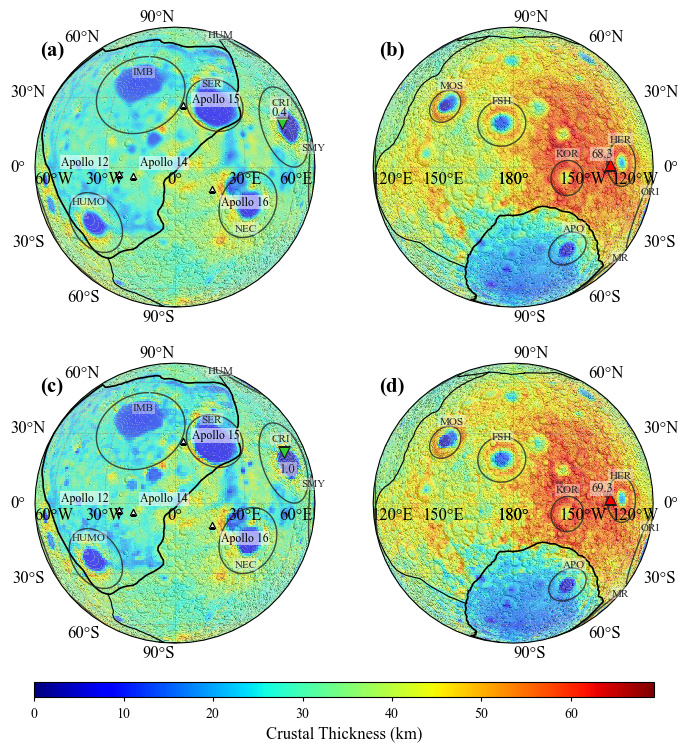

In [20]:
fig=plt.figure(figsize=(8, 10))
ls=LightSource(azdeg=315, altdeg=45)
# 计算网格
lat_mid=float(topo.lat.mean())
dx=np.deg2rad(float(topo.lon.diff('lon').mean()))*1737.4e3
dy=np.deg2rad(float(topo.lat.diff('lat').mean()))*1737.4e3

vmin1 = float(np.nanpercentile(crustthick_spherical, 0))   # 去掉最低2%
vmax1 = float(np.nanpercentile(crustthick_spherical, 100))  # 去掉最高2%
vmin2 = float(np.nanpercentile(crustthick_tesseroid, 0))   # 去掉最低2%
vmax2 = float(np.nanpercentile(crustthick_tesseroid, 100))  # 去掉最高2%
v=np.max(np.abs([vmin1,vmax1,vmin2,vmax2]))
vmin=0
vmax=v

hillshade=ls.hillshade(np.array(topo),vert_exag=10,dx=dx,dy=dy)
# a. nearside crust thickness from spherical harmonic domain inversion
ax1 = plt.subplot(2, 2, 1, projection=ccrs.Orthographic(central_longitude=0, central_latitude=0))
ax1.set_global()
pm1 = ax1.pcolormesh(
    crustthick_spherical.lon, crustthick_spherical.lat, crustthick_spherical,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    shading="auto",
    vmin=vmin, vmax=vmax)

ax1.pcolormesh(topo.lon, topo.lat, hillshade,
              transform=ccrs.PlateCarree(),alpha=hillshade_alpha,
              cmap='gray', vmin=0, vmax=1,
              shading='auto')

add_panel_label(ax1, "(a)")

ax1.gridlines(
    xlocs=np.arange(-180, 181, 30), 
    ylocs=np.arange(-90, 91, 30), 
    draw_labels=False, 
    linewidth=0.5, 
    color='gray', 
    alpha=0.5, 
    linestyle='--')

# b. farside crust thickness from spherical harmonic domain inversion
ax2 = plt.subplot(2, 2, 2, projection=ccrs.Orthographic(central_longitude=180, central_latitude=0))
ax2.set_global()
pm2 = ax2.pcolormesh(
    crustthick_spherical.lon, crustthick_spherical.lat, crustthick_spherical,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    shading="auto",
    vmin=vmin, vmax=vmax)
ax2.pcolormesh(topo.lon, topo.lat, hillshade,
              transform=ccrs.PlateCarree(),alpha=hillshade_alpha,
              cmap='gray', vmin=0, vmax=1,
              shading='auto')

add_panel_label(ax2, "(b)")

ax2.gridlines(
    xlocs=np.arange(-180, 181, 30), 
    ylocs=np.arange(-90, 91, 30), 
    draw_labels=False, 
    linewidth=0.5, 
    color='gray', 
    alpha=0.5, 
    linestyle='--')

val_max,lon_max,lat_max,val_min,lon_min,lat_min=find_extreme(crustthick_spherical)
mark_extreme(ax1, lon_max, lat_max, val_max, "^", "red")
mark_extreme(ax1, lon_min, lat_min, val_min, "v", "limegreen",text_dx=5)
mark_extreme(ax2, lon_max, lat_max, val_max, "^", "red")
mark_extreme(ax2, lon_min, lat_min, val_min, "v", "limegreen",text_dx=5)

# c. nearside crust thickness from tesseroid based inversion
ax3 = plt.subplot(2, 2, 3, projection=ccrs.Orthographic(central_longitude=0, central_latitude=0))
ax3.set_global()
pm3 = ax3.pcolormesh(
    crustthick_tesseroid.lon, crustthick_tesseroid.lat, crustthick_tesseroid,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    shading="auto",
    vmin=vmin, vmax=vmax)
ax3.pcolormesh(topo.lon, topo.lat, hillshade,
              transform=ccrs.PlateCarree(),alpha=hillshade_alpha,
              cmap='gray', vmin=0, vmax=1,
              shading='auto')

add_panel_label(ax3, "(c)")

ax3.gridlines(
    xlocs=np.arange(-180, 181, 30), 
    ylocs=np.arange(-90, 91, 30), 
    draw_labels=False, 
    linewidth=0.5, 
    color='gray', 
    alpha=0.5, 
    linestyle='--')

# d. farside crust thickness from tesseroid based inversion
ax4 = plt.subplot(2, 2, 4, projection=ccrs.Orthographic(central_longitude=180, central_latitude=0))
ax4.set_global()
pm4 = ax4.pcolormesh(
    crustthick_tesseroid.lon, crustthick_tesseroid.lat, crustthick_tesseroid,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    shading="auto",
    vmin=vmin, vmax=vmax)
ax4.pcolormesh(topo.lon, topo.lat, hillshade,
              transform=ccrs.PlateCarree(),alpha=hillshade_alpha,
              cmap='gray', vmin=0, vmax=1,
              shading='auto')

add_panel_label(ax4, "(d)")

ax4.gridlines(
    xlocs=np.arange(-180, 181, 30), 
    ylocs=np.arange(-90, 91, 30), 
    draw_labels=False, 
    linewidth=0.5, 
    color='gray', 
    alpha=0.5, 
    linestyle='--')

val_max,lon_max,lat_max,val_min,lon_min,lat_min=find_extreme(crustthick_tesseroid)
mark_extreme(ax3, lon_max, lat_max, val_max, "^", "red")
mark_extreme(ax3, lon_min, lat_min, val_min, "v", "limegreen",text_dx=5,text_dy=-10)
mark_extreme(ax4, lon_max, lat_max, val_max, "^", "red")
mark_extreme(ax4, lon_min, lat_min, val_min, "v", "limegreen",text_dx=5)

xlocs = np.arange(-180, 181, 30)
xlocs = xlocs[(xlocs != 90) & (xlocs != -90)]
ylocs = np.arange(-90, 91, 30)

for ax in [ax1, ax3]: 
    label.add_lat_labels_on_limb(ax, ylocs, side="left", offset_frac=0.07, text_kwargs={"fontsize": 12})
    label.add_lon_labels_on_equator(ax, xlocs, text_kwargs={"fontsize": 12})
    plot_boundaries_folder_on_ax(ax, 'data', thick_keywords=("SPATU","MTU"),linewidth_thick=1.2,linewidth_thin=0.8)
    label.plot_apollo_sites(ax,apollo_sites,show_labels=True)
for ax in [ax2, ax4]: 
    label.add_lat_labels_on_limb(ax, ylocs, side="right", offset_frac=0.07, text_kwargs={"fontsize": 12})
    label.add_lon_labels_on_equator(ax, xlocs, central_lonlat=(180,0), text_kwargs={"fontsize": 12})
    plot_boundaries_folder_on_ax(ax, 'data', thick_keywords=("SPATU","MTU"),linewidth_thick=1.2,linewidth_thin=0.8)

for (abbr,fullname,lat0,lon0,r_km) in basins:
    if abbr != "NEC":
        offside=(0,10)
    else:
        offside=(0,-10)
    add_basin(ax1,abbr,lat0,lon0,r_km,lw=1,alpha=0.8,n_samples=100,label_offset=offside)
    add_basin(ax2,abbr,lat0,lon0,r_km,lw=1,alpha=0.8,n_samples=100,label_offset=offside)
    add_basin(ax3,abbr,lat0,lon0,r_km,lw=1,alpha=0.8,n_samples=100,label_offset=offside)
    add_basin(ax4,abbr,lat0,lon0,r_km,lw=1,alpha=0.8,n_samples=100,label_offset=offside)

cbar=fig.colorbar(pm1,ax=[ax1,ax2,ax3,ax4],location='bottom',pad=0.05,shrink=1,aspect=40)
cbar.set_label("Crustal Thickness (km)", fontsize=12)
cbar.ax.tick_params(labelsize=10)

fig.savefig("figure/figure2_inversion_results.png",dpi=600,bbox_inches="tight")

plot density

In [21]:
import pandas as pd



df=pd.read_csv(PROJECT_ROOT / "data/density_gravity.csv")
lon = np.sort(df['lon'].unique())
lat = np.sort(df['lat'].unique())
rho         = df.pivot(index='lat', columns='lon', values='rho_anomaly') \
                .loc[lat, lon].values.astype(float)
gravity     = df.pivot(index='lat', columns='lon', values='gravity') \
                .loc[lat, lon].values.astype(float)


df         = pd.read_csv(PROJECT_ROOT / 'data/boueguer_frenquency_11km_d35km_1deg.csv')

lon = np.sort(df['lon'].unique())
lat = np.sort(df['lat'].unique())

go          = df.pivot(index='lat', columns='lon', values='deltaN') \
                .loc[lat, lon].values.astype(float)

In [22]:
rho_xr=xr.DataArray(rho,
                    dims=("lat","lon"),
                    coords={
                        "lat":lat,
                        "lon":lon
                    })
gravity_xr=xr.DataArray(gravity,
                    dims=("lat","lon"),
                    coords={
                        "lat":lat,
                        "lon":lon
                    })
go_raw_xr=xr.DataArray(go,
                   dims=("lat","lon"),
                    coords={
                        "lat":lat,
                        "lon":lon
                    })

go_xr=go_raw_xr-gravity_xr

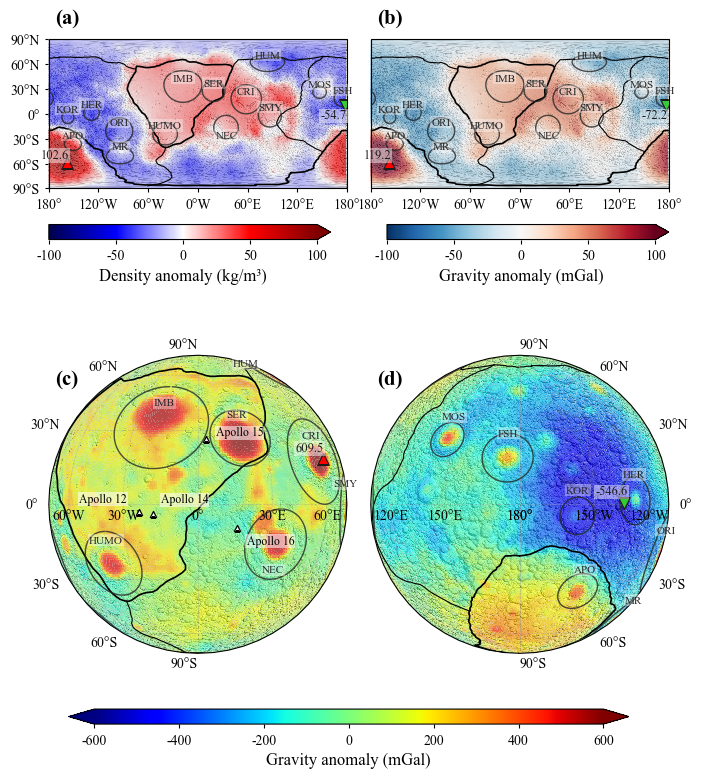

In [23]:
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter

label_size=12
tickt_size=10

fig = plt.figure(figsize=(8, 10))
ls = LightSource(azdeg=315, altdeg=45)

dx = np.deg2rad(float(topo.lon.diff('lon').mean())) * 1737.4e3
dy = np.deg2rad(float(topo.lat.diff('lat').mean())) * 1737.4e3
hillshade = ls.hillshade(np.array(topo), vert_exag=10, dx=dx, dy=dy)

def add_hillshade(ax):
    ax.pcolormesh(topo.lon, topo.lat, hillshade,
                  transform=ccrs.PlateCarree(),
                  cmap='gray', vmin=0, vmax=1,
                  alpha=hillshade_alpha, shading='auto', zorder=2)

# ==================== 上排：PlateCarree 投影 ====================
ax1 = fig.add_subplot(2, 2, 1, projection=ccrs.PlateCarree())
ax1.set_global()

v=100

pm1 = ax1.pcolormesh(rho_xr.lon, rho_xr.lat, rho_xr,
                     transform=ccrs.PlateCarree(),
                     cmap='seismic', shading="auto", vmin=-v, vmax=v, zorder=1)
add_hillshade(ax1)
add_panel_label(ax1, "(a)", y=1.2)
ax1.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
ax1.set_yticks(np.arange(-90, 91, 30),  crs=ccrs.PlateCarree())
lon_formatter = LongitudeFormatter(zero_direction_label=True)
lat_formatter = LatitudeFormatter()
ax1.xaxis.set_major_formatter(lon_formatter)
ax1.yaxis.set_major_formatter(lat_formatter)
ax1.tick_params(labelsize=tickt_size)
plot_boundaries_folder_on_ax(ax1, 'data',
                              thick_keywords=("SPATU", "MTU"),
                              linewidth_thick=1.2, linewidth_thin=0.8)

val_max, lon_max, lat_max, val_min, lon_min, lat_min = find_extreme(rho_xr)
for ax in [ax1]:
    mark_extreme(ax, lon_max, lat_max, val_max, "^", "red")
    mark_extreme(ax, lon_min, lat_min, val_min, "v", "limegreen",text_dy=-20)

ax2 = fig.add_subplot(2, 2, 2, projection=ccrs.PlateCarree())
ax2.set_global()

pm2 = ax2.pcolormesh(gravity_xr.lon, gravity_xr.lat, gravity_xr,
                     transform=ccrs.PlateCarree(),
                     cmap='RdBu_r', shading="auto", vmin=-v, vmax=v, zorder=1)
add_hillshade(ax2)
add_panel_label(ax2, "(b)", y=1.2)
ax2.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
ax2.xaxis.set_major_formatter(lon_formatter)
ax2.tick_params(labelsize=tickt_size)
plot_boundaries_folder_on_ax(ax2, 'data',   # ← 修正了原来写成 ax1 的 bug
                              thick_keywords=("SPATU", "MTU"),
                              linewidth_thick=1.2, linewidth_thin=0.8)

val_max, lon_max, lat_max, val_min, lon_min, lat_min = find_extreme(gravity_xr)
for ax in [ax2]:
    mark_extreme(ax, lon_max, lat_max, val_max, "^", "red")
    mark_extreme(ax, lon_min, lat_min, val_min, "v", "limegreen",text_dy=-20)

# 上排各自色标
for ax, pm, label_str in [(ax1, pm1, "Density anomaly (kg/m³)"),
                           (ax2, pm2, "Gravity anomaly (mGal)")]:
    
    pos = ax.get_position()
    # 色标左边对齐 ax3，右边对齐 ax4
    cbar_ax = fig.add_axes([
        pos.x0,                        # left
        pos.y0 - 0.05,                 # bottom
        pos.x1 - pos.x0,               # width
        0.015                          # height
    ])
    cbar = fig.colorbar(pm, cax=cbar_ax, location='bottom', pad=0.06, shrink=0.95, aspect=40, extend='max')
    cbar.set_label(label_str, fontsize=label_size)

# ==================== 下排：Orthographic 投影 ====================
ax3 = fig.add_subplot(2, 2, 3, projection=ccrs.Orthographic(central_longitude=0,   central_latitude=0))
ax4 = fig.add_subplot(2, 2, 4, projection=ccrs.Orthographic(central_longitude=180, central_latitude=0))

for ax in [ax3, ax4]:
    ax.set_global()
    ax.gridlines(xlocs=np.arange(-180, 181, 30),
                 ylocs=np.arange(-90,   91, 30),
                 draw_labels=False, linewidth=0.5,
                 color='gray', alpha=0.5, linestyle='--')

pm3 = ax3.pcolormesh(go_xr.lon, go_xr.lat, go_xr,
                     transform=ccrs.PlateCarree(),
                     cmap=cmap, shading="auto", zorder=1,vmax=600,vmin=-600)
add_hillshade(ax3)
add_panel_label(ax3, "(c)")

pm4 = ax4.pcolormesh(go_xr.lon, go_xr.lat, go_xr,
                     transform=ccrs.PlateCarree(),
                     cmap=cmap, shading="auto", zorder=1,vmax=600,vmin=-600)
add_hillshade(ax4)
add_panel_label(ax4, "(d)")

# 极值标记
val_max, lon_max, lat_max, val_min, lon_min, lat_min = find_extreme(go_xr)
for ax in [ax3, ax4]:
    mark_extreme(ax, lon_max, lat_max, val_max, "^", "red")
    mark_extreme(ax, lon_min, lat_min, val_min, "v", "limegreen")

# 经纬度标签
xlocs = np.arange(-180, 181, 30)
xlocs = xlocs[(xlocs != 90) & (xlocs != -90)]
ylocs = np.arange(-90, 91, 30)

label.add_lat_labels_on_limb(ax3, ylocs, side="left",  offset_frac=0.07, text_kwargs={"fontsize": 10})
label.add_lon_labels_on_equator(ax3, xlocs,                              text_kwargs={"fontsize": 10})
label.add_lat_labels_on_limb(ax4, ylocs, side="right", offset_frac=0.07, text_kwargs={"fontsize": 10})
label.add_lon_labels_on_equator(ax4, xlocs, central_lonlat=(180, 0),     text_kwargs={"fontsize": 10})

# 边界线
for ax in [ax3, ax4]:
    plot_boundaries_folder_on_ax(ax, 'data',
                                  thick_keywords=("SPATU", "MTU"),
                                  linewidth_thick=1.2, linewidth_thin=0.8)

# Apollo 站点（仅近侧）
label.plot_apollo_sites(ax3, apollo_sites, show_labels=True)

# 盆地
for (abbr, fullname, lat0, lon0, r_km) in basins:
    offside = (0, -10) if abbr == "NEC" else (0, 10)
    for ax in [ax1, ax2, ax3, ax4]:
        add_basin(ax, abbr, lat0, lon0, r_km,
                  lw=1, alpha=0.8, n_samples=100, label_offset=offside)
plt.subplots_adjust(hspace=0.15, wspace=0.08, bottom=0.15)
# 下排共用色标
cbar_ax = fig.add_axes([0.15, 0.1, 0.70, 0.015])
cbar = fig.colorbar(pm3, cax=cbar_ax, orientation='horizontal', aspect=40, extend="both")
cbar.set_label("Gravity anomaly (mGal)", fontsize=label_size)
cbar.ax.tick_params(labelsize=tickt_size)

plt.subplots_adjust(hspace=0.15, wspace=0.08)
fig.savefig("figure/figure1_densityandgravity.png", dpi=600, bbox_inches="tight")

统计直方图们